# Note

  The csv file download from this colab might be different from the one on Kaggle.  
But the overall design and procedures are the same.  

# GOAL
 **Train a model on the training set and then use the model to predict the gender column in the test set**

# Download Kaggle dataset

In [ ]:
pip install kaggle

In [ ]:
from google.colab import files

# 上傳 kaggle.json
files.upload()

# 創建 kaggle 資料夾並移動 API 憑證
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/

# 設定權限
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle competitions download -c boy-or-girl-2025-new
!unzip boy-or-girl-2025-new.zip -d ./dataset


Archive:  boy-or-girl-2025-new.zip
  inflating: ./dataset/Boy_or_girl_test_sandbox_sample_submission.csv  
  inflating: ./dataset/boy or girl 2025 test no ans_missingValue.csv  
  inflating: ./dataset/boy or girl 2025 train_missingValue.csv  


# Dataset

**boy or girl 2025 train_missingValue.csv** - the training set   
**boy or girl 2025 test no ans_missingValue.csv** - the test set   
**Boy_or_girl_test_sandbox_sample_submission.csv** - a sample submission file in the correct format   



In [ ]:
import os

dataset_path = "./dataset"
files = os.listdir(dataset_path)
print(files)


['Boy_or_girl_test_sandbox_sample_submission.csv', 'boy or girl 2025 train_missingValue.csv', 'boy or girl 2025 test no ans_missingValue.csv']


In [ ]:
import pandas as pd

train_file = "boy or girl 2025 train_missingValue.csv"
df_train = pd.read_csv(os.path.join(dataset_path, train_file))

test_file = "boy or girl 2025 test no ans_missingValue.csv"
df_test = pd.read_csv(os.path.join(dataset_path, test_file))

print(df_train)

      id  gender star_sign phone_os  height  weight  sleepiness     iq  \
0      1       2       處女座    Apple   154.0    43.0         NaN    NaN   
1      2       2       處女座    Apple   156.0    47.0         NaN  130.0   
2      3       1       射手座      NaN   170.0    61.0         NaN   90.0   
3      4       1       射手座    Apple   170.0    62.0         4.0  100.0   
4      5       2       射手座  Android   158.0    67.0         NaN  128.0   
..   ...     ...       ...      ...     ...     ...         ...    ...   
418  419       1       處女座  Android   166.0    66.0         4.0   90.0   
419  420       1       牡羊座  Android   176.0    65.0         4.0   87.0   
420  421       1       NaN    Apple   174.0    72.0         2.0    NaN   
421  422       2       天蠍座      NaN   167.0    50.0         3.0  180.0   
422  423       1       雙魚座  Android   173.0    68.0         3.0   66.0   

     fb_friends   yt                     self_intro  
0         583.0    0                      Beautiful  
1  

In [ ]:
df_train_length = len(df_train)
print(f"df_train_length: {df_train_length}")


df_test_length = len(df_test)
print(f"df_test_length: {df_test_length}")


df_train_length: 423
df_test_length: 426


In [ ]:
# 計算缺失值數量
missing_values = df_train.isnull().sum()

# 計算每個欄位缺失值的比例
missing_percentage = (missing_values / len(df_train)) * 100

# 印出缺失值數量與比例
missing_data = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage.map(lambda x: f"{x:.1f}%"),
    "Data Type": df_train.dtypes
})

print(missing_data)



            Missing Values Percentage Data Type
id                       0       0.0%     int64
gender                   0       0.0%     int64
star_sign               86      20.3%    object
phone_os                78      18.4%    object
height                  74      17.5%   float64
weight                  85      20.1%   float64
sleepiness              91      21.5%   float64
iq                      79      18.7%   float64
fb_friends              77      18.2%   float64
yt                      90      21.3%    object
self_intro             104      24.6%    object


In [ ]:
print(df_train['gender'].value_counts())  # 查看 gender 欄位的分佈


gender
1    316
2    107
Name: count, dtype: int64


# Training data

In [ ]:
# 創建獨立副本，就不會動到原始資料
# df_train_cleaned = df_train
df_train_cleaned = df_train[['id', 'gender', 'height', 'weight', 'self_intro']]
# df_train_cleaned = df_train[['id', 'gender', 'height', 'weight', 'self_intro','yt']]

# df_train_cleaned = df_train[['id', 'gender', 'height', 'weight']]

df_train_cleaned

,id,gender,height,weight,self_intro
0,1,2,154.0,43.0,Beautiful
1,2,2,156.0,47.0,Enjoying being who I'm notsss
2,3,1,170.0,61.0,Practice Makes perfect
3,4,1,170.0,62.0,Straightforward
4,5,2,158.0,67.0,Humorous
...,...,...,...,...,...
418,419,1,166.0,66.0,I hope i am a super hero.
419,420,1,176.0,65.0,NaN
420,421,1,174.0,72.0,NaN
421,422,2,167.0,50.0,NaN


## self_intro_length

In [ ]:
# 用空字串替換 NaN 值，然後計算字數
df_train_cleaned['self_intro_length'] = df_train_cleaned['self_intro'].fillna('').apply(len)

df_train_cleaned

<ipython-input-10-e0474d98b8a8>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_cleaned['self_intro_length'] = df_train_cleaned['self_intro'].fillna('').apply(len)


,id,gender,height,weight,self_intro,self_intro_length
0,1,2,154.0,43.0,Beautiful,9
1,2,2,156.0,47.0,Enjoying being who I'm notsss,29
2,3,1,170.0,61.0,Practice Makes perfect,22
3,4,1,170.0,62.0,Straightforward,15
4,5,2,158.0,67.0,Humorous,8
...,...,...,...,...,...,...
418,419,1,166.0,66.0,I hope i am a super hero.,25
419,420,1,176.0,65.0,NaN,0
420,421,1,174.0,72.0,NaN,0
421,422,2,167.0,50.0,NaN,0


## self_intro_word_count

In [ ]:
df_train_cleaned['self_intro_word_count'] = df_train_cleaned['self_intro'].fillna('').apply(lambda x: len(x.split()))
df_train_cleaned

<ipython-input-11-0f1697a94abe>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_cleaned['self_intro_word_count'] = df_train_cleaned['self_intro'].fillna('').apply(lambda x: len(x.split()))


,id,gender,height,weight,self_intro,self_intro_length,self_intro_word_count
0,1,2,154.0,43.0,Beautiful,9,1
1,2,2,156.0,47.0,Enjoying being who I'm notsss,29,5
2,3,1,170.0,61.0,Practice Makes perfect,22,3
3,4,1,170.0,62.0,Straightforward,15,1
4,5,2,158.0,67.0,Humorous,8,1
...,...,...,...,...,...,...,...
418,419,1,166.0,66.0,I hope i am a super hero.,25,7
419,420,1,176.0,65.0,NaN,0,0
420,421,1,174.0,72.0,NaN,0,0
421,422,2,167.0,50.0,NaN,0,0


## 自介關鍵字

In [ ]:
boy_keywords = [
    'handsome', 'man', 'cool', 'guy', 'gay', 'nerd', 'boy', 'dude', 'papa',
    '男', '帥'
]


girl_keywords = [
    'beautiful', 'cute', 'pretty', 'girl', 'beauty', 'adorable',
    '可愛', '女'
]

In [ ]:
import re

# 清理文字：移除標點符號 + 小寫
def clean_intro(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)  # 移除標點符號
    return text.strip()

# 關鍵字分類邏輯
def keyword_category(text):
    text = clean_intro(text)
    if not text:
        return 0
    has_boy = any(kw in text for kw in boy_keywords)
    has_girl = any(kw in text for kw in girl_keywords)
    if has_girl:
        return 2
    elif has_boy:
        return 1
    else:
        return 0

# 處理訓練集
df_train_cleaned['self_intro_clean'] = df_train_cleaned['self_intro'].fillna('').apply(clean_intro)
df_train_cleaned['keyword'] = df_train_cleaned['self_intro_clean'].apply(keyword_category)

<ipython-input-13-0eb4e3a17004>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_cleaned['self_intro_clean'] = df_train_cleaned['self_intro'].fillna('').apply(clean_intro)
<ipython-input-13-0eb4e3a17004>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_cleaned['keyword'] = df_train_cleaned['self_intro_clean'].apply(keyword_category)


In [ ]:
df_train_cleaned['self_intro_word_count'] = df_train_cleaned['self_intro'].fillna('').apply(lambda x: len(x.split()))
df_train_cleaned

<ipython-input-14-0f1697a94abe>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_cleaned['self_intro_word_count'] = df_train_cleaned['self_intro'].fillna('').apply(lambda x: len(x.split()))


,id,gender,height,weight,self_intro,self_intro_length,self_intro_word_count,self_intro_clean,keyword
0,1,2,154.0,43.0,Beautiful,9,1,beautiful,2
1,2,2,156.0,47.0,Enjoying being who I'm notsss,29,5,enjoying being who im notsss,0
2,3,1,170.0,61.0,Practice Makes perfect,22,3,practice makes perfect,0
3,4,1,170.0,62.0,Straightforward,15,1,straightforward,0
4,5,2,158.0,67.0,Humorous,8,1,humorous,0
...,...,...,...,...,...,...,...,...,...
418,419,1,166.0,66.0,I hope i am a super hero.,25,7,i hope i am a super hero,0
419,420,1,176.0,65.0,NaN,0,0,,0
420,421,1,174.0,72.0,NaN,0,0,,0
421,422,2,167.0,50.0,NaN,0,0,,0


## 身高體重

In [ ]:
# 將欄位強制轉換為數值，如果無法轉換（例如是字串或亂碼），就會變成 NaN
df_train_cleaned['height'] = pd.to_numeric(df_train_cleaned['height'], errors='coerce')
df_train_cleaned['weight'] = pd.to_numeric(df_train_cleaned['weight'], errors='coerce')

# 計算身高的 IQR
Q1_height = df_train_cleaned['height'].quantile(0.25)
Q3_height = df_train_cleaned['height'].quantile(0.75)
IQR_height = Q3_height - Q1_height

# 計算體重的 IQR
Q1_weight = df_train_cleaned['weight'].quantile(0.25)
Q3_weight = df_train_cleaned['weight'].quantile(0.75)
IQR_weight = Q3_weight - Q1_weight

# 計算 BMI
df_train_cleaned['BMI'] = df_train_cleaned['weight'] / (df_train_cleaned['height'] / 100) ** 2  # 假設身高是以公分為單位，轉換為公尺

# 計算 BMI 的 IQR
Q1_bmi = df_train_cleaned['BMI'].quantile(0.25)
Q3_bmi = df_train_cleaned['BMI'].quantile(0.75)
IQR_bmi = Q3_bmi - Q1_bmi

# 計算異常值的範圍
lower_bound_height = Q1_height - 3 * IQR_height
upper_bound_height = Q3_height + 3 * IQR_height

lower_bound_weight = Q1_weight - 3 * IQR_weight
upper_bound_weight = Q3_weight + 3 * IQR_weight

lower_bound_bmi = Q1_bmi - 3 * IQR_bmi
upper_bound_bmi = Q3_bmi + 3 * IQR_bmi

# 使用 pandas 來控制顯示數字的格式
pd.set_option('display.float_format', '{:.6f}'.format)

# 尋找異常值
outliers_height = df_train_cleaned[(df_train_cleaned['height'] < lower_bound_height) | (df_train_cleaned['height'] > upper_bound_height)]
outliers_weight = df_train_cleaned[(df_train_cleaned['weight'] < lower_bound_weight) | (df_train_cleaned['weight'] > upper_bound_weight)]
outliers_bmi = df_train_cleaned[(df_train_cleaned['BMI'] < lower_bound_bmi) | (df_train_cleaned['BMI'] > upper_bound_bmi)]

# 過濾掉異常值
df_no_outliers = df_train_cleaned[(df_train_cleaned['height'] >= lower_bound_height) & (df_train_cleaned['height'] <= upper_bound_height) &
                                  (df_train_cleaned['weight'] >= lower_bound_weight) & (df_train_cleaned['weight'] <= upper_bound_weight) &
                                  (df_train_cleaned['BMI'] >= lower_bound_bmi) & (df_train_cleaned['BMI'] <= upper_bound_bmi)]

# 按性別分組並計算平均身高和體重
average_by_gender = df_no_outliers.groupby('gender')[['height', 'weight', 'BMI']].mean().round(1)

# 顯示性別分組結果
print(average_by_gender)

# 計算整個資料集的平均身高、體重和BMI
overall_average = df_no_outliers[['height', 'weight', 'BMI']].mean().round(1)

# 顯示整個資料集的平均值
print("\n整個資料集的平均身高、體重和BMI：")
print(overall_average)


           height    weight       BMI
gender                               
1      173.400000 67.300000 22.400000
2      160.600000 54.800000 21.300000

整個資料集的平均身高、體重和BMI：
height   170.400000
weight    64.400000
BMI       22.100000
dtype: float64


<ipython-input-15-56b9518edae1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_cleaned['height'] = pd.to_numeric(df_train_cleaned['height'], errors='coerce')
<ipython-input-15-56b9518edae1>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_cleaned['weight'] = pd.to_numeric(df_train_cleaned['weight'], errors='coerce')
<ipython-input-15-56b9518edae1>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

## 增加BMI欄位

In [ ]:
df_train_cleaned['BMI'] = df_train_cleaned['weight'] / (df_train_cleaned['height'] / 100)**2

df_train_cleaned

<ipython-input-16-e8670c053b2c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_cleaned['BMI'] = df_train_cleaned['weight'] / (df_train_cleaned['height'] / 100)**2


,id,gender,height,weight,self_intro,self_intro_length,self_intro_word_count,self_intro_clean,keyword,BMI
0,1,2,154.000000,43.000000,Beautiful,9,1,beautiful,2,18.131219
1,2,2,156.000000,47.000000,Enjoying being who I'm notsss,29,5,enjoying being who im notsss,0,19.312952
2,3,1,170.000000,61.000000,Practice Makes perfect,22,3,practice makes perfect,0,21.107266
3,4,1,170.000000,62.000000,Straightforward,15,1,straightforward,0,21.453287
4,5,2,158.000000,67.000000,Humorous,8,1,humorous,0,26.838648
...,...,...,...,...,...,...,...,...,...,...
418,419,1,166.000000,66.000000,I hope i am a super hero.,25,7,i hope i am a super hero,0,23.951227
419,420,1,176.000000,65.000000,NaN,0,0,,0,20.983988
420,421,1,174.000000,72.000000,NaN,0,0,,0,23.781213
421,422,2,167.000000,50.000000,NaN,0,0,,0,17.928215


## 平均身高體重BMI

In [ ]:
# 男性平均身高和體重
male_avg_height = average_by_gender.loc[1, 'height']
male_avg_weight = average_by_gender.loc[1, 'weight']
# 男性的平均 BMI
male_avg_bmi = df_no_outliers[df_no_outliers['gender'] == 1]['BMI'].mean().round(1)

# 女性平均身高和體重
female_avg_height = average_by_gender.loc[2, 'height']
female_avg_weight = average_by_gender.loc[2, 'weight']
# 女性的平均 BMI
female_avg_bmi = df_no_outliers[df_no_outliers['gender'] == 2]['BMI'].mean().round(1)

#整個資料集的
all_avg_height = overall_average[['height']].mean().round(1)
all_avg_weight =  overall_average[['weight']].mean().round(1)
all_avg_bmi = overall_average[['BMI']].mean().round(1)

# 顯示結果
print(f"男性的平均身高: {male_avg_height} cm, 男性的平均體重: {male_avg_weight} kg, 男性的平均BMI: {male_avg_bmi}")
print(f"女性的平均身高: {female_avg_height} cm, 女性的平均體重: {female_avg_weight} kg, 女性的平均BMI: {female_avg_bmi}")
print(f"全部的平均身高: {all_avg_height} cm, 全部的平均體重: {all_avg_weight} kg, 全部的平均BMI: {all_avg_bmi}")



男性的平均身高: 173.4 cm, 男性的平均體重: 67.3 kg, 男性的平均BMI: 22.4
女性的平均身高: 160.6 cm, 女性的平均體重: 54.8 kg, 女性的平均BMI: 21.3
全部的平均身高: 170.4 cm, 全部的平均體重: 64.4 kg, 全部的平均BMI: 22.1


In [ ]:

print(f"Average height of males: {male_avg_height} cm, average weight of males: {male_avg_weight} kg, average BMI of males: {male_avg_bmi}")
print(f"Average height of females: {female_avg_height} cm, average weight of females: {female_avg_weight} kg, average BMI of females: {female_avg_bmi}")
print(f"Overall average height: {all_avg_height} cm, overall average weight: {all_avg_weight} kg, overall average BMI: {all_avg_bmi}")


Average height of males: 173.4 cm, average weight of males: 67.3 kg, average BMI of males: 22.4
Average height of females: 160.6 cm, average weight of females: 54.8 kg, average BMI of females: 21.3
Overall average height: 170.4 cm, overall average weight: 64.4 kg, overall average BMI: 22.1


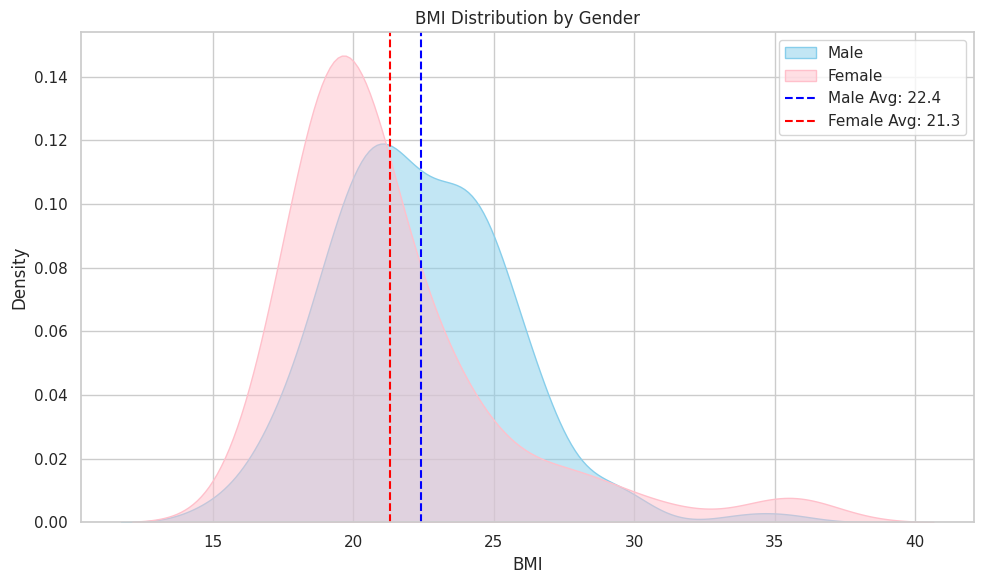

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# 畫出男女分開的 BMI 分布
sns.kdeplot(data=df_no_outliers[df_no_outliers['gender'] == 1], x="BMI", label="Male", fill=True, color="skyblue", alpha=0.5)
sns.kdeplot(data=df_no_outliers[df_no_outliers['gender'] == 2], x="BMI", label="Female", fill=True, color="pink", alpha=0.5)

# 加上平均值的直線
plt.axvline(x=average_by_gender.loc[1, 'BMI'], color='blue', linestyle='--', label=f"Male Avg: {average_by_gender.loc[1, 'BMI']}")
plt.axvline(x=average_by_gender.loc[2, 'BMI'], color='red', linestyle='--', label=f"Female Avg: {average_by_gender.loc[2, 'BMI']}")

# 圖表標題與標籤
plt.title("BMI Distribution by Gender")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


## 補缺漏&異常值

In [ ]:
import numpy as np

# 定義異常值範圍
def is_outlier(value, lower_bound, upper_bound):
    return value < lower_bound or value > upper_bound

lower_bound_height = Q1_height - 3 * IQR_height
upper_bound_height = Q3_height + 3 * IQR_height
lower_bound_weight = Q1_weight - 3 * IQR_weight
upper_bound_weight = Q3_weight + 3 * IQR_weight

# 定義補齊缺失值和異常值
def fill_missing_or_outlier(row):
    # 如果身高或體重是負數，先將其轉為正數
    if row['height'] < 0:
        row['height'] = abs(row['height'])
    if row['weight'] < 0:
        row['weight'] = abs(row['weight'])

    # 檢查身高、體重的異常值和缺失值
    height_is_outlier = is_outlier(row['height'], lower_bound_height, upper_bound_height)
    weight_is_outlier = is_outlier(row['weight'], lower_bound_weight, upper_bound_weight)

    if pd.isnull(row['height']) and pd.isnull(row['weight']):
        # 如果身高體重都是缺失值，則補上該性別的平均身高和體重
        if row['gender'] == 1:
            row['height'] = male_avg_height
            row['weight'] = male_avg_weight
        elif row['gender'] == 2:
            row['height'] = female_avg_height
            row['weight'] = female_avg_weight

    elif height_is_outlier and weight_is_outlier:
        # 如果身高體重都是異常值，則補上1
        row['height'] = 1
        row['weight'] = 1

    elif height_is_outlier and not weight_is_outlier:
        # 如果只有身高是異常值，則根據性別平均的體重來補齊身高
        if row['gender'] == 1:
            row['height'] = male_avg_height
        elif row['gender'] == 2:
            row['height'] = female_avg_height

    elif not height_is_outlier and weight_is_outlier:
        # 如果只有體重是異常值，則根據性別平均的身高來補齊體重
        if row['gender'] == 1:
            row['weight'] = male_avg_weight
        elif row['gender'] == 2:
            row['weight'] = female_avg_weight

    elif pd.isnull(row['height']) and not pd.isnull(row['weight']):
        # 如果只有身高缺失，則根據性別平均的 BMI 計算缺失的身高，並轉換為公分
        if row['gender'] == 1:
            row['height'] = (row['weight'] / male_avg_bmi) ** 0.5 * 100
        elif row['gender'] == 2:
            row['height'] = (row['weight'] / female_avg_bmi) ** 0.5 * 100

    elif not pd.isnull(row['height']) and pd.isnull(row['weight']):
        # 如果只有體重缺失，則根據性別平均的 BMI 計算缺失的體重
        if row['gender'] == 1:
            row['weight'] = male_avg_bmi * (row['height'] / 100) ** 2
        elif row['gender'] == 2:
            row['weight'] = female_avg_bmi * (row['height'] / 100) ** 2

    return row


df_train_cleaned = df_train_cleaned.apply(fill_missing_or_outlier, axis=1)
df_train_cleaned

,id,gender,height,weight,self_intro,self_intro_length,self_intro_word_count,self_intro_clean,keyword,BMI,BMI_bin,height_bin,combo_keyword_bmi,combo_keyword_height
0,1,2,154.000000,43.000000,Beautiful,9,1,beautiful,2,18.131219,1,2,2_1,2_2
1,2,2,156.000000,47.000000,Enjoying being who I'm notsss,29,5,enjoying being who im notsss,0,19.312952,2,2,0_2,0_2
2,3,1,170.000000,61.000000,Practice Makes perfect,22,3,practice makes perfect,0,21.107266,2,3,0_2,0_3
3,4,1,170.000000,62.000000,Straightforward,15,1,straightforward,0,21.453287,2,3,0_2,0_3
4,5,2,158.000000,67.000000,Humorous,8,1,humorous,0,26.838648,4,2,0_4,0_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,419,1,166.000000,66.000000,I hope i am a super hero.,25,7,i hope i am a super hero,0,23.951227,3,3,0_3,0_3
419,420,1,176.000000,65.000000,NaN,0,0,,0,20.983988,2,4,0_2,0_4
420,421,1,174.000000,72.000000,NaN,0,0,,0,23.781213,3,4,0_3,0_4
421,422,2,167.000000,50.000000,NaN,0,0,,0,17.928215,1,3,0_1,0_3


## 重新計算每個人的BMI

In [ ]:
df_train_cleaned['BMI'] = df_train_cleaned['weight'] / (df_train_cleaned['height'] / 100)**2
df_train_cleaned

,id,gender,height,weight,self_intro,self_intro_length,self_intro_word_count,self_intro_clean,keyword,BMI,BMI_bin,height_bin,combo_keyword_bmi,combo_keyword_height
0,1,2,154.000000,43.000000,Beautiful,9,1,beautiful,2,18.131219,1,2,2_1,2_2
1,2,2,156.000000,47.000000,Enjoying being who I'm notsss,29,5,enjoying being who im notsss,0,19.312952,2,2,0_2,0_2
2,3,1,170.000000,61.000000,Practice Makes perfect,22,3,practice makes perfect,0,21.107266,2,3,0_2,0_3
3,4,1,170.000000,62.000000,Straightforward,15,1,straightforward,0,21.453287,2,3,0_2,0_3
4,5,2,158.000000,67.000000,Humorous,8,1,humorous,0,26.838648,4,2,0_4,0_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,419,1,166.000000,66.000000,I hope i am a super hero.,25,7,i hope i am a super hero,0,23.951227,3,3,0_3,0_3
419,420,1,176.000000,65.000000,NaN,0,0,,0,20.983988,2,4,0_2,0_4
420,421,1,174.000000,72.000000,NaN,0,0,,0,23.781213,3,4,0_3,0_4
421,422,2,167.000000,50.000000,NaN,0,0,,0,17.928215,1,3,0_1,0_3


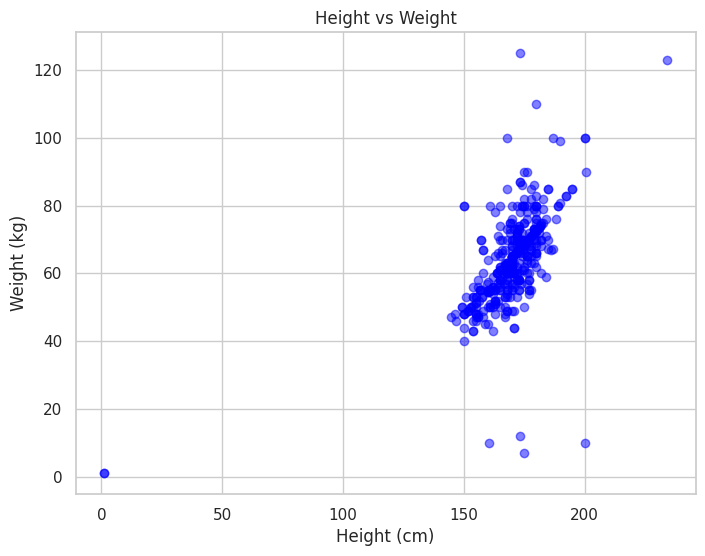

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df_train_cleaned['height'], df_train_cleaned['weight'], alpha=0.5, color='blue')

plt.title('Height vs Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.grid(True)
plt.show()


## 建立組合特徵

In [ ]:
# BMI 分類
df_train_cleaned['BMI_bin'] = pd.cut(df_train_cleaned['BMI'],
                             bins=[0, 10, 18.5, 22, 25, 30, 10000],
                             labels=['0', '1', '2', '3', '4', '5'])

# 身高分類
df_train_cleaned['height_bin'] = pd.cut(df_train_cleaned['height'],
                                bins=[0, 130, 150, 160, 170, 180, 200, 10000],
                                labels=['0', '1', '2', '3', '4', '5', '6'])

# combo 欄位
df_train_cleaned['combo_keyword_bmi'] = df_train_cleaned['keyword'].astype(str) + '_' + df_train_cleaned['BMI_bin'].astype(str)
df_train_cleaned['combo_keyword_height'] = df_train_cleaned['keyword'].astype(str) + '_' + df_train_cleaned['height_bin'].astype(str)


## 查看

In [ ]:
# df_train_cleaned = df_train_cleaned.drop(columns=['intro_type', 'pred_gender'])
df_train_cleaned

,id,gender,height,weight,self_intro,self_intro_length,self_intro_word_count,self_intro_clean,keyword,BMI,BMI_bin,height_bin,combo_keyword_bmi,combo_keyword_height
0,1,2,154.000000,43.000000,Beautiful,9,1,beautiful,2,18.131219,1,2,2_1,2_2
1,2,2,156.000000,47.000000,Enjoying being who I'm notsss,29,5,enjoying being who im notsss,0,19.312952,2,2,0_2,0_2
2,3,1,170.000000,61.000000,Practice Makes perfect,22,3,practice makes perfect,0,21.107266,2,3,0_2,0_3
3,4,1,170.000000,62.000000,Straightforward,15,1,straightforward,0,21.453287,2,3,0_2,0_3
4,5,2,158.000000,67.000000,Humorous,8,1,humorous,0,26.838648,4,2,0_4,0_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,419,1,166.000000,66.000000,I hope i am a super hero.,25,7,i hope i am a super hero,0,23.951227,3,3,0_3,0_3
419,420,1,176.000000,65.000000,NaN,0,0,,0,20.983988,2,4,0_2,0_4
420,421,1,174.000000,72.000000,NaN,0,0,,0,23.781213,3,4,0_3,0_4
421,422,2,167.000000,50.000000,NaN,0,0,,0,17.928215,1,3,0_1,0_3


# 特徵工程


## 資料準備

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

X = df_train_cleaned.drop(columns=['gender', 'self_intro','self_intro_clean', 'BMI_bin', 'height_bin'])
y = df_train_cleaned['gender']

## 訓練方式

In [ ]:
def train_best_xgb_model(X, y, cv_folds=10):
    from xgboost import XGBClassifier
    from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
    from sklearn.preprocessing import LabelEncoder
    import pandas as pd
    import numpy as np

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # 計算 scale_pos_weight（處理類別不平衡）
    num_class0 = sum(y_encoded == 0)
    num_class1 = sum(y_encoded == 1)
    scale_pos_weight = num_class0 / num_class1
    print(f"scale_pos_weight = {scale_pos_weight:.4f}")

    # 將 object 類別轉為 category
    X_processed = X.copy()
    for col in X_processed.select_dtypes(include='object').columns:
        X_processed[col] = X_processed[col].astype('category')

    # 初始模型（用來取得特徵重要性）
    base_model = XGBClassifier(
        eval_metric='logloss',
        enable_categorical=True,
        use_label_encoder=False,
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )
    base_model.fit(X_processed, y_encoded)

    # 特徵重要性排序
    importances = base_model.feature_importances_
    sorted_features = X_processed.columns[np.argsort(importances)[::-1]]

    # 特徵篩選（每次增加一個特徵 → 看交叉驗證準確率）
    def evaluate_feature_subset(X, y, sorted_features, learning_rate=1, cv=10):
        best_score = 0
        best_features = []
        for i in range(3, len(sorted_features) + 1):
            current_features = sorted_features[:i]
            X_subset = X[current_features]
            model = XGBClassifier(
                learning_rate=learning_rate,
                enable_categorical=True,
                eval_metric='logloss',
                scale_pos_weight=scale_pos_weight,
                random_state=42
            )
            score = cross_val_score(model, X_subset, y, cv=cv, scoring='accuracy').mean()
            print(f"Top {i} features → Accuracy: {score:.4f}")
            if score > best_score:
                best_score = score
                best_features = current_features
        return best_features, best_score

    # 開始篩選特徵
    selected_features, best_feature_score = evaluate_feature_subset(
        X_processed, y_encoded, sorted_features, learning_rate=1, cv=cv_folds
    )

    print(f"最佳特徵數量：{len(selected_features)}，CV 準確率：{best_feature_score:.4f}")
    print("選中的特徵如下：")
    for feat in selected_features:
        print(f" - {feat}")

    X_selected = X_processed[selected_features]

    # 調整參數
    param_grid = {
        'learning_rate': [0.2, 0.27, 0.28, 0.3],
        'max_depth': [3, 4, 5,],
        # 防止over fitting
        'reg_alpha': [ 0.1, 0.16, 0.17, 0.18],
        'reg_lambda': [2.5, 2.6, 2.7]
    }

    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    grid_search = GridSearchCV(
        estimator=XGBClassifier(
            enable_categorical=True,
            eval_metric='logloss',
            scale_pos_weight=scale_pos_weight,
            random_state=42
        ),
        param_grid=param_grid,
        scoring='accuracy',
        cv=skf,
        verbose=1,
        n_jobs=-1
    )

    grid_search.fit(X_selected, y_encoded)

    print("最佳參數：", grid_search.best_params_)
    print("最佳調參後 CV 準確率：", grid_search.best_score_)

    # 最終模型訓練
    best_model = XGBClassifier(
        eval_metric='logloss',
        enable_categorical=True,
        learning_rate=grid_search.best_params_['learning_rate'],
        max_depth=grid_search.best_params_['max_depth'],
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )
    best_model.fit(X_selected, y_encoded)

    return {
        "model": best_model,
        "selected_features": selected_features,
        "label_encoder": le,
        "grid_search": grid_search,
        "sorted_features": sorted_features
    }


## 找最佳參數

In [ ]:

result = train_best_xgb_model(X, y)

X_selected = X[result['selected_features']].copy()

# object → category
for col in X_selected.select_dtypes(include='object').columns:
    X_selected[col] = X_selected[col].astype('category')

# 預測 + 還原 label
y_pred_encoded = result['model'].predict(X_selected)
y_pred = result['label_encoder'].inverse_transform(y_pred_encoded)


scale_pos_weight = 2.9533


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:51:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Top 3 features → Accuracy: 0.9008
Top 4 features → Accuracy: 0.9385
Top 5 features → Accuracy: 0.9409
Top 6 features → Accuracy: 0.9291
Top 7 features → Accuracy: 0.9268
Top 8 features → Accuracy: 0.9269
Top 9 features → Accuracy: 0.9246
最佳特徵數量：5，CV 準確率：0.9409
選中的特徵如下：
 - combo_keyword_height
 - height
 - keyword
 - BMI
 - weight
Fitting 10 folds for each of 144 candidates, totalling 1440 fits
最佳參數： {'learning_rate': 0.28, 'max_depth': 4, 'reg_alpha': 0.1, 'reg_lambda': 2.6}
最佳調參後 CV 準確率： 0.9549280177187154


In [ ]:
from sklearn.metrics import accuracy_score

# 整份訓練資料的準確率
X_train_final = X[result['selected_features']].copy()
for col in X_train_final.select_dtypes(include='object').columns:
    X_train_final[col] = X_train_final[col].astype('category')

y_train_pred = result['model'].predict(X_train_final)
y_train_pred_label = result['label_encoder'].inverse_transform(y_train_pred)

train_acc = accuracy_score(y, y_train_pred_label)
cv_acc = result['grid_search'].best_score_

print(f"訓練集準確率：{train_acc:.4f}")
print(f"交叉驗證準確率：{cv_acc:.4f}")


訓練集準確率：0.9953
交叉驗證準確率：0.9549


## 畫圖

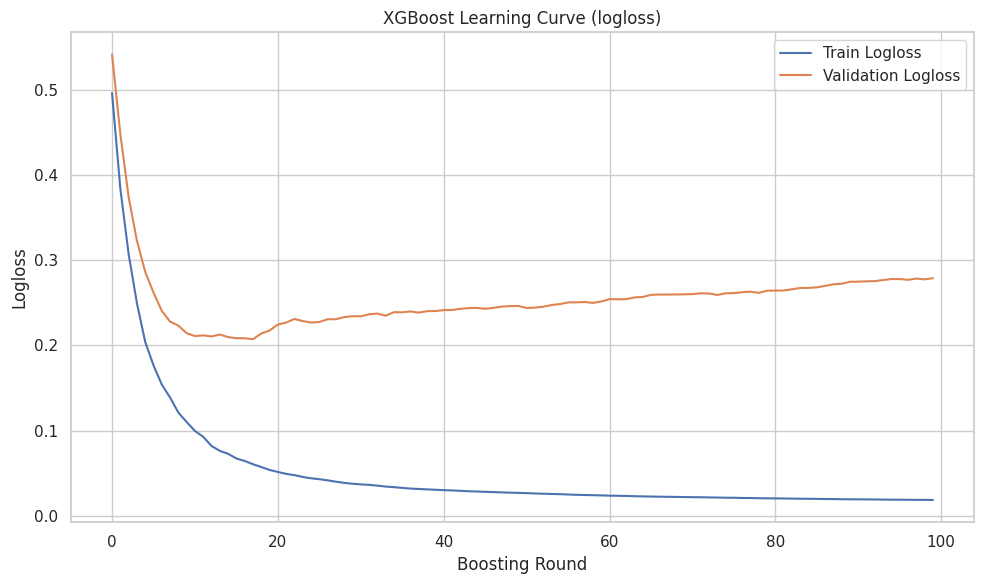

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import xgboost as xgb


X_sample = X[result['selected_features']].copy()
for col in X_sample.select_dtypes(include='object').columns:
    X_sample[col] = X_sample[col].astype('category')


y_encoded = result['label_encoder'].transform(y)

# 切分訓練/驗證集
X_train, X_val, y_train, y_val = train_test_split(
    X_sample, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 建立模型
model = xgb.XGBClassifier(
    learning_rate=result['grid_search'].best_params_['learning_rate'],
    max_depth=result['grid_search'].best_params_['max_depth'],
    enable_categorical=True,
    eval_metric='logloss',
    scale_pos_weight=(sum(y_encoded == 0) / sum(y_encoded == 1)),
    n_estimators=100,
    random_state=42
)

# 訓練模型
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

evals_result = model.evals_result()

# 畫圖
epochs = len(evals_result['validation_0']['logloss'])
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), evals_result['validation_0']['logloss'], label='Train Logloss')
plt.plot(range(epochs), evals_result['validation_1']['logloss'], label='Validation Logloss')
plt.xlabel("Boosting Round")
plt.ylabel("Logloss")
plt.title("XGBoost Learning Curve (logloss)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 有一點點over fitting， 所以加入early stopping

In [ ]:
# 訓練模型
model = xgb.XGBClassifier(
    learning_rate=result['grid_search'].best_params_['learning_rate'],
    max_depth=result['grid_search'].best_params_['max_depth'],
    reg_alpha=result['grid_search'].best_params_.get('reg_alpha', 0.17),
    reg_lambda=result['grid_search'].best_params_.get('reg_lambda', 2.6),
    enable_categorical=True,
    eval_metric='logloss',
    scale_pos_weight=(sum(y_encoded == 0) / sum(y_encoded == 1)),
    n_estimators=300,  # 固定 round 數
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)


evals_result = model.evals_result()

# 找出最佳 round
val_logloss = evals_result['validation_0']['logloss']
best_round = int(np.argmin(val_logloss))
print(f"最佳 round：{best_round}")


最佳 round：17


## 建最終的模型

In [ ]:
X_final = X[result['selected_features']].copy()
for col in X_final.select_dtypes(include='object').columns:
    X_final[col] = X_final[col].astype('category')
y_final = result['label_encoder'].transform(y)

# 重新訓練模型，用最佳 round
final_model = xgb.XGBClassifier(
    learning_rate=result['grid_search'].best_params_['learning_rate'],
    max_depth=result['grid_search'].best_params_['max_depth'],
    reg_alpha=result['grid_search'].best_params_.get('reg_alpha', 0.17),
    reg_lambda=result['grid_search'].best_params_.get('reg_lambda', 2.6),
    enable_categorical=True,
    eval_metric='logloss',
    scale_pos_weight=(sum(y_final == 0) / sum(y_final == 1)),
    n_estimators=13,  ########### 用最佳的round
    random_state=42
)

final_model.fit(X_final, y_final)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.28, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=13,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
# 儲存模型
import pickle

with open("final_xgb_model.pkl", "wb") as f:
    pickle.dump({
        "model": final_model,
        "selected_features": result['selected_features'],
        "label_encoder": result['label_encoder']
    }, f)

# Testing data

In [ ]:
df_test_cleaned = df_test[['id', 'gender', 'height', 'weight', 'self_intro']]
# df_test_cleaned = df_test[['id', 'gender', 'height', 'weight', 'self_intro','yt']]

# 用空字串替換 NaN 值，然後計算字數
df_test_cleaned['self_intro_length'] = df_test_cleaned['self_intro'].fillna('').apply(len)
df_test_cleaned['self_intro_word_count'] = df_test_cleaned['self_intro'].fillna('').apply(lambda x: len(x.split()))


df_test_cleaned

<ipython-input-66-79e4b3214799>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_cleaned['self_intro_length'] = df_test_cleaned['self_intro'].fillna('').apply(len)
<ipython-input-66-79e4b3214799>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_cleaned['self_intro_word_count'] = df_test_cleaned['self_intro'].fillna('').apply(lambda x: len(x.split()))


,id,gender,height,weight,self_intro,self_intro_length,self_intro_word_count
0,1,0,200.000000,100.000000,GOod,4,1
1,2,0,175.000000,80.000000,Easygoing,9,1
2,3,0,155.000000,45.000000,NaN,0,0
3,4,0,173.000000,85.000000,NaN,0,0
4,5,0,164.000000,57.000000,I'm smart,9,2
...,...,...,...,...,...,...,...
421,422,0,160.000000,70.000000,I am a girl.,12,4
422,423,0,162.000000,54.000000,NaN,0,0
423,424,0,173.000000,66.000000,I like to play basketball.,26,5
424,425,0,165.000000,53.000000,Good,4,1


## 清理自我介紹

In [ ]:
df_test_cleaned['self_intro_clean'] = df_test_cleaned['self_intro'].fillna('').apply(clean_intro)
df_test_cleaned['keyword'] = df_test_cleaned['self_intro_clean'].apply(keyword_category)

df_test_cleaned

<ipython-input-67-fd91d3769245>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_cleaned['self_intro_clean'] = df_test_cleaned['self_intro'].fillna('').apply(clean_intro)
<ipython-input-67-fd91d3769245>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_cleaned['keyword'] = df_test_cleaned['self_intro_clean'].apply(keyword_category)


,id,gender,height,weight,self_intro,self_intro_length,self_intro_word_count,self_intro_clean,keyword
0,1,0,200.000000,100.000000,GOod,4,1,good,0
1,2,0,175.000000,80.000000,Easygoing,9,1,easygoing,0
2,3,0,155.000000,45.000000,NaN,0,0,,0
3,4,0,173.000000,85.000000,NaN,0,0,,0
4,5,0,164.000000,57.000000,I'm smart,9,2,im smart,1
...,...,...,...,...,...,...,...,...,...
421,422,0,160.000000,70.000000,I am a girl.,12,4,i am a girl,2
422,423,0,162.000000,54.000000,NaN,0,0,,0
423,424,0,173.000000,66.000000,I like to play basketball.,26,5,i like to play basketball,0
424,425,0,165.000000,53.000000,Good,4,1,good,0


## 補身高體重缺漏異常 (不知道為啥要多跑幾次才清的乾淨)

In [ ]:
def get_neighbor_mean(series, index, window=3):

    start = max(0, index - window)
    end = min(len(series), index + window + 1)
    neighbor_values = series[start:end].dropna()

    if not neighbor_values.empty:
        return neighbor_values.mean()
    else:
        return np.nan  # 如果鄰近值都為 NaN，就回傳 NaN


In [ ]:
# 小數點一位
def fill_missing_or_outlier_test_v3(df):
    for i, row in df.iterrows():
        h, w = row['height'], row['weight']

        # 轉正數
        if pd.notnull(h) and h < 0:
            h = abs(h)
        if pd.notnull(w) and w < 0:
            w = abs(w)

        # 判斷異常
        h_outlier = is_outlier(h, lower_bound_height, upper_bound_height)
        w_outlier = is_outlier(w, lower_bound_weight, upper_bound_weight)

        # 身高體重都缺失就補平均
        if pd.isnull(h) and pd.isnull(w):
            h = round(all_avg_height, 1)
            w = round(all_avg_weight, 1)

        # 身高體重都異常就補 1
        elif h_outlier and w_outlier:
            h = 1
            w = 1

        # 身高異常  用 BMI 估
        elif h_outlier and not w_outlier:
            h = round((w / all_avg_bmi) ** 0.5 * 100, 1)

        # 體重異常  用鄰近平均補
        elif not h_outlier and w_outlier:
            w = round(get_neighbor_mean(df['weight'], i), 1)

        # 身高缺失  用 BMI 估
        elif pd.isnull(h) and not pd.isnull(w):
            h = round((w / all_avg_bmi) ** 0.5 * 100, 1)

        # 體重缺失 用 鄰近平均補
        elif not pd.isnull(h) and pd.isnull(w):
            w = round(get_neighbor_mean(df['weight'], i), 1)

        df.at[i, 'height'] = h
        df.at[i, 'weight'] = w

    return df

df_test_cleaned = fill_missing_or_outlier_test_v3(df_test_cleaned)
df_test_cleaned[['height', 'weight']] = df_test_cleaned[['height', 'weight']].round(1)

df_test_cleaned = df_test_cleaned.sort_values(by='id').reset_index(drop=True)
df_test_cleaned

<ipython-input-69-77af0d1f1c2f>:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_cleaned[['height', 'weight']] = df_test_cleaned[['height', 'weight']].round(1)


,id,gender,height,weight,self_intro,self_intro_length,self_intro_word_count,self_intro_clean,keyword
0,1,0,200.000000,100.000000,GOod,4,1,good,0
1,2,0,175.000000,80.000000,Easygoing,9,1,easygoing,0
2,3,0,155.000000,45.000000,NaN,0,0,,0
3,4,0,173.000000,85.000000,NaN,0,0,,0
4,5,0,164.000000,57.000000,I'm smart,9,2,im smart,1
...,...,...,...,...,...,...,...,...,...
421,422,0,160.000000,70.000000,I am a girl.,12,4,i am a girl,2
422,423,0,162.000000,54.000000,NaN,0,0,,0
423,424,0,173.000000,66.000000,I like to play basketball.,26,5,i like to play basketball,0
424,425,0,165.000000,53.000000,Good,4,1,good,0


## BMI

In [ ]:
df_test_cleaned['BMI'] = df_test_cleaned['weight'] / (df_test_cleaned['height'] / 100)**2
df_test_cleaned

,id,gender,height,weight,self_intro,self_intro_length,self_intro_word_count,self_intro_clean,keyword,BMI
0,1,0,200.000000,100.000000,GOod,4,1,good,0,25.000000
1,2,0,175.000000,80.000000,Easygoing,9,1,easygoing,0,26.122449
2,3,0,155.000000,45.000000,NaN,0,0,,0,18.730489
3,4,0,173.000000,85.000000,NaN,0,0,,0,28.400548
4,5,0,164.000000,57.000000,I'm smart,9,2,im smart,1,21.192742
...,...,...,...,...,...,...,...,...,...,...
421,422,0,160.000000,70.000000,I am a girl.,12,4,i am a girl,2,27.343750
422,423,0,162.000000,54.000000,NaN,0,0,,0,20.576132
423,424,0,173.000000,66.000000,I like to play basketball.,26,5,i like to play basketball,0,22.052190
424,425,0,165.000000,53.000000,Good,4,1,good,0,19.467401


## 組合特徵 關鍵字

In [ ]:
# 轉成數值，無法轉換的設為 NaN
df_test_cleaned['height'] = pd.to_numeric(df_test_cleaned['height'], errors='coerce')
df_test_cleaned['weight'] = pd.to_numeric(df_test_cleaned['weight'], errors='coerce')

# # BMI
# df_test_cleaned['BMI'] = df_test_cleaned['weight'] / (df_test_cleaned['height'] / 100) ** 2

# BMI 分類
df_test_cleaned['BMI_bin'] = pd.cut(
    df_test_cleaned['BMI'],
    bins=[0, 10, 18.5, 22, 25, 30, 10000],
    labels=['0', '1', '2', '3', '4', '5']
)

# 身高分類
df_test_cleaned['height_bin'] = pd.cut(
    df_test_cleaned['height'],
    bins=[130, 150, 160, 170, 180, 200, 10000],
    labels=['1', '2', '3', '4', '5', '6']
)

# 關鍵字
girl_keywords = ['beautiful', 'cute', 'pretty', 'girl', 'beauty', 'adorable', '可愛', '女']
boy_keywords = ['handsome', 'man', 'cool', 'smart', 'happy', 'guy', 'gay', 'nerd', 'boy', 'dude', 'papa', '男', '帥']

# 自我介紹 關鍵字 分類
df_test_cleaned['self_intro_clean'] = df_test_cleaned['self_intro'].fillna('').str.lower()

def keyword_category(text):
    if not text.strip():
        return 0
    has_boy = any(kw in text for kw in boy_keywords)
    has_girl = any(kw in text for kw in girl_keywords)
    if has_girl:
        return 2
    elif has_boy:
        return 1
    else:
        return 0

df_test_cleaned['keyword'] = df_test_cleaned['self_intro_clean'].apply(keyword_category)

# combo 欄位
df_test_cleaned['combo_keyword_bmi'] = df_test_cleaned['keyword'].astype(str) + '_' + df_test_cleaned['BMI_bin'].astype(str)
df_test_cleaned['combo_keyword_height'] = df_test_cleaned['keyword'].astype(str) + '_' + df_test_cleaned['height_bin'].astype(str)


## 查看

In [ ]:
df_test_cleaned

,id,gender,height,weight,self_intro,self_intro_length,self_intro_word_count,self_intro_clean,keyword,BMI,BMI_bin,height_bin,combo_keyword_bmi,combo_keyword_height
0,1,0,200.000000,100.000000,GOod,4,1,good,0,25.000000,3,5,0_3,0_5
1,2,0,175.000000,80.000000,Easygoing,9,1,easygoing,0,26.122449,4,4,0_4,0_4
2,3,0,155.000000,45.000000,NaN,0,0,,0,18.730489,2,2,0_2,0_2
3,4,0,173.000000,85.000000,NaN,0,0,,0,28.400548,4,4,0_4,0_4
4,5,0,164.000000,57.000000,I'm smart,9,2,i'm smart,1,21.192742,2,3,1_2,1_3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,422,0,160.000000,70.000000,I am a girl.,12,4,i am a girl.,2,27.343750,4,2,2_4,2_2
422,423,0,162.000000,54.000000,NaN,0,0,,0,20.576132,2,3,0_2,0_3
423,424,0,173.000000,66.000000,I like to play basketball.,26,5,i like to play basketball.,0,22.052190,3,4,0_3,0_4
424,425,0,165.000000,53.000000,Good,4,1,good,0,19.467401,2,3,0_2,0_3


# Predict

In [ ]:
result_to_submit = pd.DataFrame({
    'id': df_test_cleaned['id'],
})

In [ ]:
X_test_final = df_test_cleaned[result['selected_features']].copy()

# 類別轉 category
for col in X_test_final.select_dtypes(include='object').columns:
    X_test_final[col] = X_test_final[col].astype('category')

# 還原 label
y_test_pred_encoded = final_model.predict(X_test_final)
y_test_pred = result['label_encoder'].inverse_transform(y_test_pred_encoded)

# 存預測結果
result_to_submit['gender'] = y_test_pred

result_to_submit[['gender']].value_counts()

,count
gender,
1,266
2,160


In [ ]:
from google.colab import files

result_to_submit[['id', 'gender']].to_csv("sumbit.csv", index=False)

files.download('sumbit.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>